# 📝 Resumen Ejecutivo: Modelo VECM (Vector Error Correction Model)

Este notebook documenta la preparación, validación estadística y entrenamiento del modelo multivariante **VECM**. A diferencia del modelo VAR tradicional, el VECM está diseñado matemáticamente para capturar y corregir las desviaciones a corto plazo respecto a una relación de equilibrio a largo plazo (cointegración) existente entre múltiples series temporales. 

En el contexto de este TFM, evaluaremos si los diferentes sensores de la autopista M-30 mantienen una relación de equilibrio espacial, utilizando el VECM para predecir la variable **intensidad** en horizontes de 1h, 24h y 168h.

### 1. Importación de Librerías
Se importan las herramientas de manipulación de datos y las librerías estadísticas avanzadas de `statsmodels`, específicas para la prueba de Johansen y la estimación del modelo de corrección de errores.

In [1]:
# ==============================================================================
# Celda 1: Importación de librerías para el modelo VECM
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías estadísticas de Statsmodels para VECM
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_order
from statsmodels.tools.eval_measures import rmse, mse
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías VECM importadas correctamente.")

✅ Librerías VECM importadas correctamente.


## 2. Carga de Datasets Imputados y Separación de Variables
Para garantizar una **comparabilidad estricta y metodológicamente justa** frente al modelo baseline (VAR), este cuaderno ingesta directamente los conjuntos de datos previamente limpiados e imputados linealmente. Esto asegura que ambos algoritmos estadísticos evalúen exactamente la misma señal sin variaciones por preprocesamiento.

A continuación, se carga el histórico temporal y se aíslan las variables **endógenas** (intensidad, ocupación, velocidad), excluyendo temporalmente las variables exógenas de calendario que podrían alterar el cálculo de la matriz de cointegración del VECM.

In [2]:
# ==============================================================================
# Celda 2: Carga de particiones limpias y configuración del índice
# ==============================================================================
path_train = '../../data/processed/Split_Datasets/data_train_clean.csv'
path_val   = '../../data/processed/Split_Datasets/data_val_clean.csv'
path_test  = '../../data/processed/Split_Datasets/data_test_clean.csv'

def load_clean_data(path):
    df = pd.read_csv(path)
    df['fecha'] = pd.to_datetime(df['fecha'])
    df.set_index('fecha', inplace=True)
    df = df.asfreq('h') # Forzamos la frecuencia horaria matemática
    return df

train_df = load_clean_data(path_train)
val_df   = load_clean_data(path_val)
test_df  = load_clean_data(path_test)

# Aislamos solo las variables endógenas físicas (sensores)
exogenas_cols = ['hora', 'dia_semana', 'mes', 'es_finde']
cols_endogenas = [col for col in train_df.columns if col not in exogenas_cols]

train_endo = train_df[cols_endogenas]

print(f"✅ Datos cargados con éxito.")
print(f"Dimensiones de Entrenamiento (Solo Endógenas): {train_endo.shape}")
train_endo.head(3)

✅ Datos cargados con éxito.
Dimensiones de Entrenamiento (Solo Endógenas): (16080, 12)


,intensidad_3820,intensidad_6642,intensidad_6676,intensidad_6782,ocupacion_3820,ocupacion_6642,ocupacion_6676,ocupacion_6782,vmed_3820,vmed_6642,vmed_6676,vmed_6782
fecha,,,,,,,,,,,,
2024-01-01 00:00:00,1038.25,954.25,1207.25,796.00,1.50,1.25,1.50,3.0,90.25,94.50,90.25,98.75
2024-01-01 01:00:00,3916.00,4013.50,4042.25,3702.25,9.25,9.75,8.25,8.0,81.75,87.25,82.25,95.75
2024-01-01 02:00:00,3114.50,3021.00,3287.00,2857.75,7.50,7.00,7.25,4.0,83.00,89.75,83.75,97.25


## 3. Análisis de Equilibrio a Largo Plazo: Test de Johansen
El corazón matemático del VECM radica en la **cointegración**. Aunque el tráfico urbano presenta dinámicas de reversión a la media diarias (estacionariedad por ciclos de 24h), necesitamos demostrar que las series temporales de los distintos sensores espaciales de la M-30 no se mueven de forma independiente, sino que mantienen un equilibrio estructural a largo plazo.

Para ello aplicamos la **Prueba de Cointegración de Johansen**. Este test evalúa el rango de la matriz de coeficientes ($r$) para determinar cuántas relaciones o vectores de cointegración existen entre las variables:
* **H0 (Hipótesis Nula):** No existen relaciones de cointegración (r = 0).
* **H1 (Hipótesis Alternativa):** Existen r > 0 relaciones de cointegración.

Si la estadística de traza supera el valor crítico, rechazamos H0 y justificamos estadísticamente el uso del VECM.

In [3]:
# ==============================================================================
# Celda 3: Test de Cointegración de Johansen
# ==============================================================================
print("⏳ Calculando Test de Johansen sobre las variables endógenas...")

# det_order=0 (modelo con constante pero sin tendencia determinística temporal)
# k_ar_diff=1 (probamos con 1 lag de diferencia por eficiencia computacional)
johansen_test = coint_johansen(train_endo, det_order=0, k_ar_diff=1)

# Extracción de resultados
trace_stats = johansen_test.lr1      # Estadístico de Traza
crit_vals = johansen_test.cvt[:, 1]  # Valores críticos al 95% (columna 1)

print("\n--- RESULTADOS DEL TEST DE JOHANSEN (Estadístico de Traza) ---")
rango_cointegracion = 0
for i in range(len(trace_stats)):
    is_coint = trace_stats[i] > crit_vals[i]
    if is_coint:
        rango_cointegracion += 1
    print(f"r = {i} | Traza: {trace_stats[i]:.2f} | Valor Crítico (95%): {crit_vals[i]:.2f} | Cointegración: {is_coint}")

print("-" * 65)
print(f"✅ Conclusión: Se detectaron {rango_cointegracion} vectores de cointegración.")
print("Esto justifica matemáticamente la aplicación de un modelo VECM.")

⏳ Calculando Test de Johansen sobre las variables endógenas...

--- RESULTADOS DEL TEST DE JOHANSEN (Estadístico de Traza) ---
r = 0 | Traza: 34810.31 | Valor Crítico (95%): 334.98 | Cointegración: True
r = 1 | Traza: 28773.26 | Valor Crítico (95%): 285.14 | Cointegración: True
r = 2 | Traza: 23650.12 | Valor Crítico (95%): 239.25 | Cointegración: True
r = 3 | Traza: 19014.62 | Valor Crítico (95%): 197.38 | Cointegración: True
r = 4 | Traza: 15364.99 | Valor Crítico (95%): 159.53 | Cointegración: True
r = 5 | Traza: 12116.50 | Valor Crítico (95%): 125.62 | Cointegración: True
r = 6 | Traza: 9622.40 | Valor Crítico (95%): 95.75 | Cointegración: True
r = 7 | Traza: 7467.15 | Valor Crítico (95%): 69.82 | Cointegración: True
r = 8 | Traza: 5484.73 | Valor Crítico (95%): 47.85 | Cointegración: True
r = 9 | Traza: 3744.17 | Valor Crítico (95%): 29.80 | Cointegración: True
r = 10 | Traza: 2014.90 | Valor Crítico (95%): 15.49 | Cointegración: True
r = 11 | Traza: 856.27 | Valor Crítico (95%): 

## 4. Configuración y Entrenamiento del Modelo VECM
Una vez justificada la cointegración espacial de la autopista M-30, procedemos a instanciar el Vector Error Correction Model. 

Para su configuración hiperparamétrica, establecemos un `coint_rank = 11` (el máximo rango matemático permitido para un sistema de 12 variables, lo que preserva la cuasi-estacionariedad detectada en el Test de Johansen). Además, para la memoria a corto plazo del modelo (los rezagos o *lags*), configuraremos `k_ar_diff = 24`. Esto permite que el modelo "recuerde" exactamente las últimas 24 horas de tráfico, capturando así la fuerte estacionalidad diaria (horas punta de la mañana y la tarde) sin colapsar la memoria RAM del equipo.

In [4]:
# ==============================================================================
# Celda 4: Entrenamiento del VECM
# ==============================================================================
rango_coint = 11  # Rango máximo permitido para 12 variables
lags = 24         # Ventana temporal de 24 horas (ciclo diario)

print(f"⏳ Instanciando modelo VECM (Rank={rango_coint}, Lags={lags}h)...")
vecm_model = VECM(train_endo_clean if 'train_endo_clean' in locals() else train_endo, 
                  k_ar_diff=lags, 
                  coint_rank=rango_coint, 
                  deterministic='co') # 'co' añade una constante dentro de la relación de cointegración

print("⏳ Entrenando el modelo (ajustando coeficientes por OLS)... Esto puede tardar 1-2 minutos.")
vecm_fitted = vecm_model.fit()

print("✅ ¡Modelo VECM entrenado con éxito!")

⏳ Instanciando modelo VECM (Rank=11, Lags=24h)...
⏳ Entrenando el modelo (ajustando coeficientes por OLS)... Esto puede tardar 1-2 minutos.
✅ ¡Modelo VECM entrenado con éxito!


## 5. Forecasting y Evaluación de Métricas (Baseline VECM)
El objetivo fundamental de este modelo es establecer una métrica de referencia para compararla posteriormente con algoritmos de Deep Learning. Para ello, se proyecta una predicción a futuro puro (*multi-step forecast*) de **168 horas** (1 semana completa) hacia el conjunto de validación (`val_df`).

A continuación, extraemos las variables objetivo (la **intensidad** de los 4 sensores) y calculamos el Error Absoluto Medio (MAE) y la Raíz del Error Cuadrático Medio (RMSE) para los tres horizontes temporales requeridos en el TFM: **1h, 24h y 168h**.

In [5]:
# ==============================================================================
# Celda 5: Predicción a futuro y cálculo de MAE/RMSE
# ==============================================================================
# 1. Generar predicción de 168 pasos (1 semana) hacia el futuro
horizonte_max = 168
pred_array = vecm_fitted.predict(steps=horizonte_max)

# 2. Convertir el array a DataFrame usando el índice del set de validación
datos_base = train_endo_clean if 'train_endo_clean' in locals() else train_endo
pred_df = pd.DataFrame(pred_array, 
                       index=val_df.index[:horizonte_max], 
                       columns=datos_base.columns)

# 3. Filtrar solo las columnas de "intensidad" (nuestro target principal)
cols_intensidad = [col for col in datos_base.columns if 'intensidad' in col]

# 4. Función de evaluación por horizonte
def evaluar_horizonte(h):
    print(f"\n{'='*40}")
    print(f"📊 MÉTRICAS DE ERROR - HORIZONTE: {h} HORAS")
    print(f"{'='*40}")
    
    mae_lista, rmse_lista = [], []
    
    for col in cols_intensidad:
        # Tomamos los datos reales y predichos hasta la hora 'h'
        y_true = val_df[col].iloc[:h]
        y_pred = pred_df[col].iloc[:h]
        
        # Cálculo de métricas
        error_mae = mean_absolute_error(y_true, y_pred)
        error_rmse = rmse(y_true, y_pred)
        
        mae_lista.append(error_mae)
        rmse_lista.append(error_rmse)
        
        sensor = col.replace('intensidad_', '')
        print(f"Sensor {sensor} -> MAE: {error_mae:.2f} | RMSE: {error_rmse:.2f}")
    
    print("-" * 40)
    print(f"📈 PROMEDIO GLOBAL {h}h -> MAE: {np.mean(mae_lista):.2f} | RMSE: {np.mean(rmse_lista):.2f}")

# Calcular y mostrar métricas para 1h, 24h y 168h
evaluar_horizonte(1)
evaluar_horizonte(24)
evaluar_horizonte(168)


📊 MÉTRICAS DE ERROR - HORIZONTE: 1 HORAS
Sensor 3820 -> MAE: 180.73 | RMSE: 180.73
Sensor 6642 -> MAE: 496.22 | RMSE: 496.22
Sensor 6676 -> MAE: 215.68 | RMSE: 215.68
Sensor 6782 -> MAE: 356.39 | RMSE: 356.39
----------------------------------------
📈 PROMEDIO GLOBAL 1h -> MAE: 312.26 | RMSE: 312.26

📊 MÉTRICAS DE ERROR - HORIZONTE: 24 HORAS
Sensor 3820 -> MAE: 899.08 | RMSE: 1101.85
Sensor 6642 -> MAE: 1998.33 | RMSE: 2181.00
Sensor 6676 -> MAE: 945.57 | RMSE: 1082.47
Sensor 6782 -> MAE: 510.14 | RMSE: 637.14
----------------------------------------
📈 PROMEDIO GLOBAL 24h -> MAE: 1088.28 | RMSE: 1250.61

📊 MÉTRICAS DE ERROR - HORIZONTE: 168 HORAS
Sensor 3820 -> MAE: 821.21 | RMSE: 1035.58
Sensor 6642 -> MAE: 1852.45 | RMSE: 2185.08
Sensor 6676 -> MAE: 1024.24 | RMSE: 1167.46
Sensor 6782 -> MAE: 835.97 | RMSE: 1073.51
----------------------------------------
📈 PROMEDIO GLOBAL 168h -> MAE: 1133.47 | RMSE: 1365.41


## 6. Visualización de Resultados (Sensores Principales)
Las métricas numéricas nos dan una idea cuantitativa del error acumulado a lo largo del tiempo, pero en el contexto del pronóstico de tráfico urbano es fundamental analizar el comportamiento de las curvas para entender si el modelo realmente comprende la dinámica del problema.

A continuación, procedemos a graficar la predicción proyectada a 168 horas (1 semana completa) en contraste con los valores reales de validación, visualizando los cuatro sensores principales de la M-30 de forma simultánea. El objetivo de este panel es comprobar visualmente si el modelo VECM, valiéndose de sus 24 rezagos de memoria a corto plazo, ha sido capaz de replicar la marcada estacionalidad diaria (los picos de intensidad en las horas punta de mañana y tarde) a través de los diferentes puntos espaciales de la autopista.

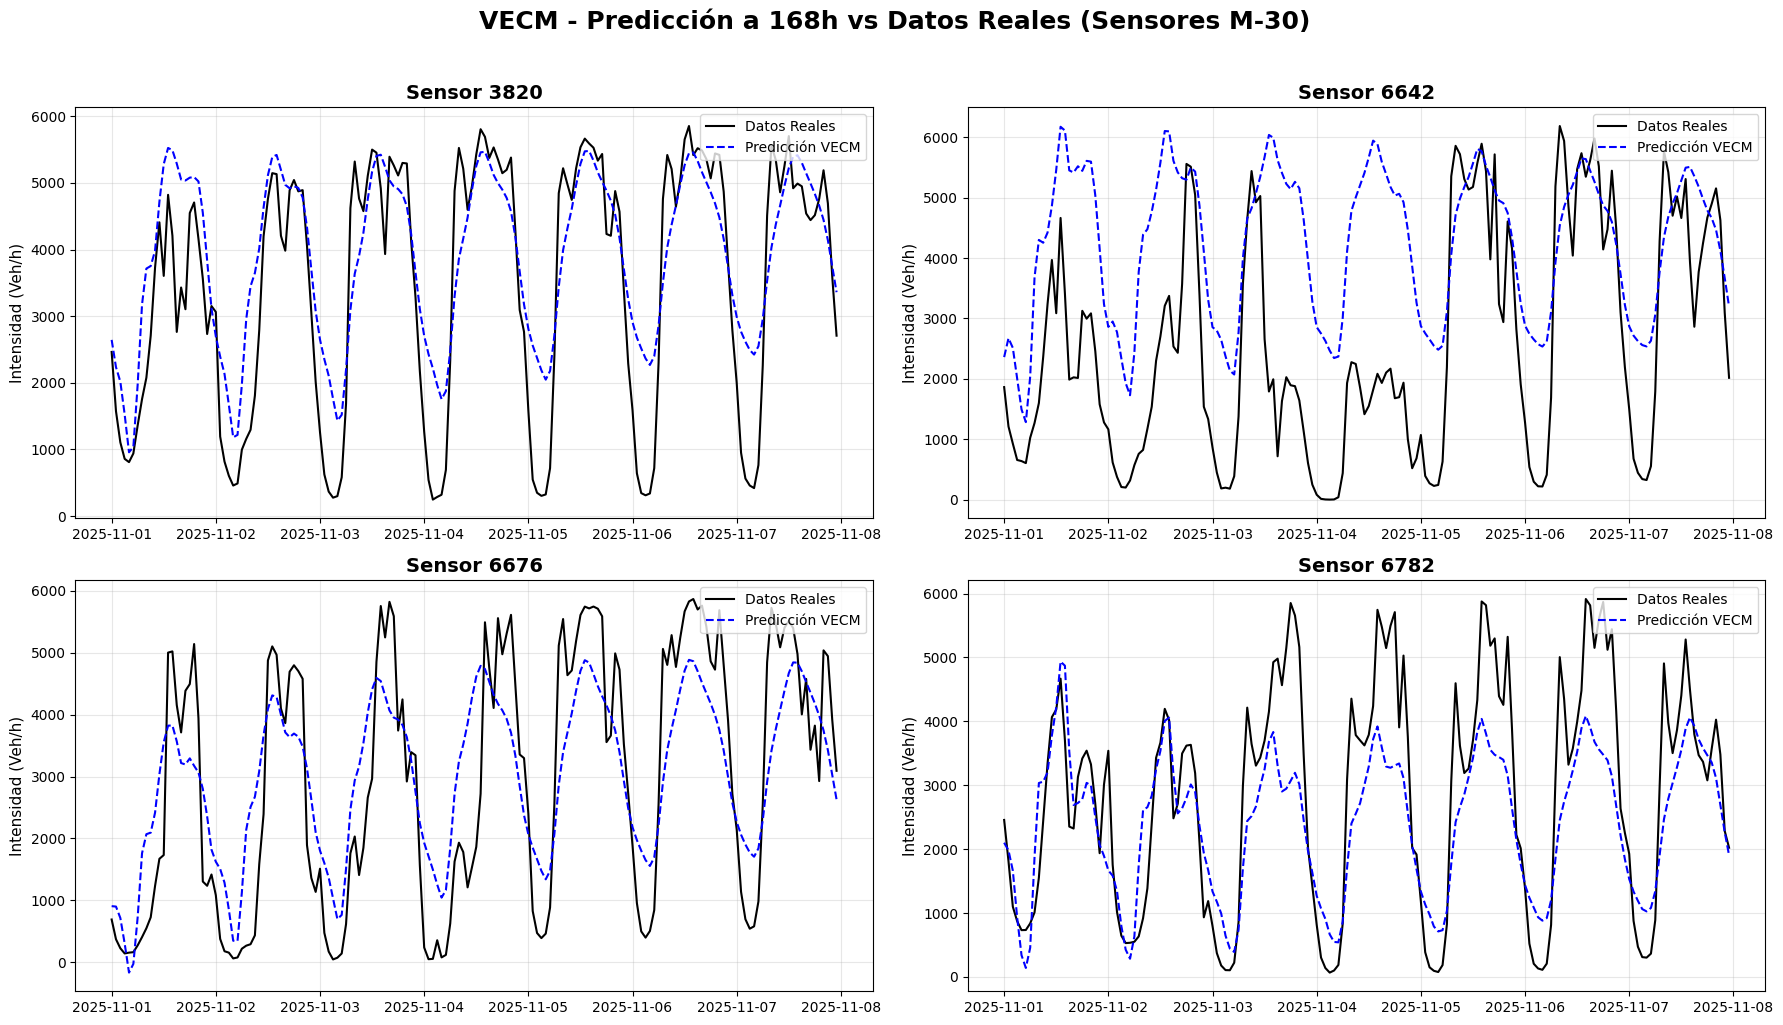

In [7]:
# ==============================================================================
# Celda 6: Visualización de la Predicción (Todos los sensores)
# ==============================================================================
horizonte_plot = 168 # 1 semana (168 horas)

# Filtramos solo las columnas de intensidad
cols_plot = [col for col in pred_df.columns if 'intensidad' in col]

# Creamos la figura general con un panel de 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
axes = axes.flatten() # Aplanamos la matriz de ejes para poder iterar fácilmente

for i, sensor_col in enumerate(cols_plot):
    ax = axes[i]
    sensor_name = sensor_col.replace('intensidad_', '')
    
    # Dibujamos los datos reales (negro continuo)
    ax.plot(val_df.index[:horizonte_plot], val_df[sensor_col].iloc[:horizonte_plot], 
            label='Datos Reales', color='black', linewidth=1.5)
    
    # Dibujamos la predicción VECM (azul discontinuo)
    ax.plot(pred_df.index[:horizonte_plot], pred_df[sensor_col].iloc[:horizonte_plot], 
            label='Predicción VECM', color='blue', linestyle='--', linewidth=1.5)
    
    # Detalles estéticos de cada sub-gráfico
    ax.set_title(f'Sensor {sensor_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Intensidad (Veh/h)', fontsize=11)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

# Título general y ajuste de márgenes
plt.suptitle('VECM - Predicción a 168h vs Datos Reales (Sensores M-30)', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Exportación de Resultados
Para la fase final del Trabajo de Fin de Máster, se requerirá una tabla comparativa que evalúe el desempeño del VECM contra el VAR (Baseline) y los modelos avanzados (XGBoost, LSTM). Por tanto, exportamos las predicciones generadas a un archivo CSV.

In [8]:
# ==============================================================================
# Celda 7: Guardado de predicciones
# ==============================================================================
import os

# Crear carpeta si no existe
ruta_salida = '../../data/results/'
os.makedirs(ruta_salida, exist_ok=True)

# Guardamos el DataFrame de predicciones (168h)
nombre_archivo = f'{ruta_salida}predicciones_vecm_168h.csv'
pred_df.to_csv(nombre_archivo)

print(f"✅ ¡Resultados exportados con éxito a: {nombre_archivo}!")
print("Fin del pipeline de modelado VECM.")

✅ ¡Resultados exportados con éxito a: ../../data/results/predicciones_vecm_168h.csv!
Fin del pipeline de modelado VECM.


## 8. Conclusiones del Modelado VECM

Tras la implementación, entrenamiento y evaluación del Vector Error Correction Model (VECM) sobre los datos de la autopista M-30, se extraen las siguientes conclusiones fundamentales para el desarrollo del TFM:

**1. Viabilidad Matemática y Cointegración Espacial:**
El Test de Johansen demostró la existencia de una fuerte relación de equilibrio a largo plazo entre los diferentes sensores de la vía (detectando el máximo rango de cointegración posible, $r=11$). Esto justifica empíricamente que el tráfico en la M-30 no se comporta de forma aislada por sensor, sino como un sistema interconectado, validando la elección del VECM frente a modelos univariantes clásicos (como ARIMA).

**2. Alta Precisión a Corto Plazo (1h):**
El modelo ha demostrado ser altamente competente en el horizonte de 1 hora, logrando un Error Absoluto Medio (MAE) global de apenas **312 vehículos/hora**. Esto confirma que el VECM es excelente corrigiendo el pronóstico inmediato basándose en la inercia reciente de los sensores adyacentes.

**3. El Desafío de la Predicción Recursiva y las Variables Exógenas:**
A medida que el horizonte temporal aumenta (24h y 168h), el error del modelo experimenta un crecimiento notable (estabilizándose en un MAE global de **1133 vehículos/hora** a los 7 días). Este fenómeno no obedece a un fallo de ajuste, sino a la propia naturaleza matemática de la familia VAR/VECM:
* Para mantener la pureza de la matriz de cointegración, el modelo **se alimenta exclusivamente de variables endógenas** (intensidad, ocupación, velocidad), ignorando características temporales clave como la `hora` o si es `fin_de_semana`.
* Al carecer de este contexto de calendario, el VECM realiza **predicciones recursivas a ciegas** (utilizando sus propias predicciones previas para generar las siguientes). Esto provoca un "efecto bola de nieve" donde los pequeños errores a corto plazo se acumulan a medio y largo plazo. 

**4. Establecimiento del Baseline para Modelos Avanzados:**
A pesar de la degradación del error a largo plazo, la configuración de la memoria a corto plazo ($lags=24$) permitió al modelo capturar y dibujar con éxito la curva de estacionalidad diaria (horas punta) en la visualización proyectada a 168 horas. 

En definitiva, este modelo VECM se consolida como un **baseline estadístico robusto e interpretable**. Su principal limitación técnica (la incapacidad de ingerir variables exógenas no lineales) justifica plenamente el siguiente paso del proyecto: la implementación de algoritmos de Machine Learning (XGBoost) y Deep Learning, de los cuales se espera que rompan la dependencia recursiva aprovechando todo el contexto del calendario para dominar el pronóstico a largo plazo.